# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 8. Вероятность


**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить по ссылке "Сдача ДЗ" на <a href="https://thetahat.ru/courses/ad"><b>странице курса</b></a>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте и на сайте, они являются строгими.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф -3 скор-балла к итоговой оценке.**
     
     * Решение теоретических задач оформляйте в markdown-ячейках формате $\LaTeX$. При решении можно использовать ИИ-инструменты только для оформления написанного самостоятельно решения. Например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.
     
     * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>


**Баллы за задание**

* Задача 1 &mdash; 60 баллов
* Задача 2 &mdash; 40 баллов
* Задача 3 &mdash; 100 баллов

In [11]:
# Bot check

# HW_ID: fpmi_ad8
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial

sns.set(style="whitegrid", palette="Set2")

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована


---
### Задача 1.

**При решении данной задачи можно использовать ИИ-инструменты только для построения графиков и оформления документации к коду. Использование ИИ-инструментов для решения контеста запрещено.**

Современные библиотеки для генерации используют алгоритмы вроде PCG64 (Permuted Congruential Generator-64), который достаточно быстро генерирует случайные 64-битные целые числа. Если их отнормировать на максимально возможное число ($2^{64}-1$), мы получим равномерное распределение $U(0, 1)$.

В рамках этой задачи для лучшего понимания взаимосвязей случайных величин мы пойдем другим путем. Будем предполагать, что у нас имеется только симметричная монета, один бросок которой моделирует случайную величину из бернуллиевского распределения с параметром $p = 0.5$.

In [13]:
# Создаем генератор случайных чисел
rng = np.random.default_rng()
# Фиксируем первые два аргумента функции rng.integers (low=0 и high=2)
coin = partial(rng.integers, 0, 2)

Вам предстоит написать собственные генераторы выборок из равномерного, нормального и экспоненциального распределений с заданными параметрами, используя в качестве основы исключительно броски правильной монеты. Совершать броски можно неограниченное количество раз. Тем не менее, поскольку лишние броски увеличивают время генерации, стоит использовать оптимальное количество бросков. За лишнее количество бросков могут быть сняты баллы.

**1.** Напишите функцию **`uniform`** генерации случайных величин из равномерного распределения на отрезке $[0, 1]$ с заданной точностью. Это можно сделать, записав случайную величину $\xi \sim U(0, 1)$ в двоичной системе системе счисления $\xi = 0,\xi_1\xi_2\xi_3...$. Тогда $\xi_i \sim Bern(1/2)$ и независимы в совокупности. Приближение заключается в том, что вместо генерации бесконечного количества $\xi_i$ мы полагаем $\xi = 0,\xi_1\xi_2\xi_3...\xi_n$.

Нужно реализовать функцию `uniform` так, чтобы она могла принимать на вход в качестве параметра `size` как число, так и объект `tuple` любой размерности, и возвращать объект `numpy.array` соответствующей размерности. Например, если `size=(10, 1, 5)`, то функция должна вернуть объект размера $10 \times 1 \times 5$. Аргумент `n_bits` отвечает за число $n$.

Также обратите внимание, что  функцию `coin` можно вызвать только один раз. Для совершения 10 бросков монеты используйте `coin(10)`, это считается одним вызовом функции. При реализации функций генерации нельзя использовать какие-либо циклы, а также функции `np.vectorize`, `np.apply_along_axis`, `np.fromiter` и подобные, это медленно и по сути является циклом. Используйте векторные функции `numpy`. При нарушении этих правил будут сниматься баллы.

In [14]:
coin(10)

array([1, 0, 0, 0, 1, 0, 0, 0, 1, 1])

In [15]:
import math

def uniform(size: int | tuple = 1, n_bits: int = 50) -> float | np.ndarray:
    """
    Генерирует выборку из непрерывного равномерного распределения U(0, 1).

    Параметры
    ---------
    size: Размерность выходного массива (одно число для вектора или кортеж для тензора).
    n_bits: Количество бросков честной монеты (битов) для аппроксимации одного вещественного числа.

    Возвращает
    ----------
    Сгенерированные значения из равномерного распределения на интервале [0, 1].
    """

    if isinstance(size, int):
      if size <= 0:
        raise ValueError("Размер выборки должен быть положителен")
      total = size
    elif isinstance(size, tuple):
      if not all(isinstance(x, int) and x > 0 for x in size):
        raise ValueError("Все параметры в size должны быть положительными целыми числами")
      total = np.prod(size)
    else:
      raise TypeError(f"Ожидался int или tuple, а получен {type(size)}")

    coins = coin(total * n_bits).reshape(total, n_bits)
    powers = 2.0 ** (-np.arange(1, 1 + n_bits))

    uniform_array = np.dot(coins, powers)
    if isinstance(size, tuple):
      return uniform_array.reshape(size)

    return uniform_array[0] if size == 1 else uniform_array

Cгенерируйте $200$ независимых случайных величин, постройте график плотности на отрезке $[-0.25, 1.25]$, а также гистограмму по сгенерированным случайным величинам. Для построения графика необходимо брать достаточно большое количество точек сетки.

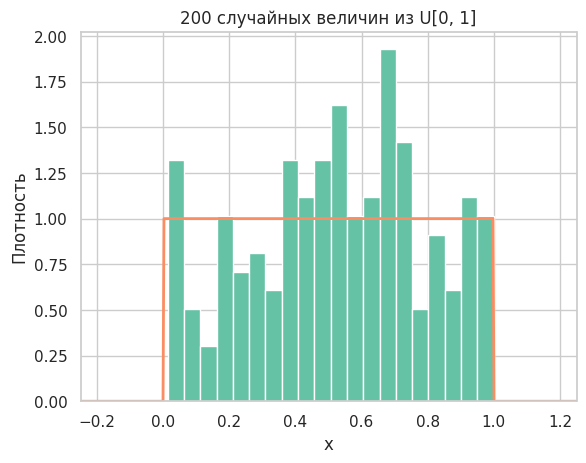

In [16]:
X_sample = uniform(200)
x = np.linspace(-0.25, 1.25, 500)
y = ((0 <= x) & (x <= 1)).astype(int)
plt.hist(X_sample, bins=20, density=True)
plt.plot(x, y, linewidth=2)
plt.title("200 случайных величин из U[0, 1]")
plt.xlim(-0.25, 1.25)
plt.xlabel("x")
plt.ylabel("Плотность")
plt.show()

Исследуйте, как меняются значения случайных величин в зависимости от `n_bits` в написанной ранее вами функции.

`n_bits` влияет на точность числа.
Например используя `n_bits` равным 32 мы получаем число с 32 знаками после запятой. Посмотрим, что происходит при малых `n_bits`
- `n_bits = 1` :
$$X_1 \in \left\{ 0, \frac{1}{2}\right\}$$
- `n_bits = 2` :
$$X_2 \in \left\{ 0, \frac{1}{4}, \frac{1}{2}, \frac{3}{4}\right\}$$

Пре увеличении n шаг сетки становится меньше -> числа плотнее заполняют отрезок [0, 1]

- При `n_bits = n` случайная величина равномерно распределена на множестве
$$\left\{ 0, \frac{1}{2^n},..., \frac{2^n - 1}{2^n}\right\}$$

Причем $\mathbb{E}[X_n] = 1/2 - 2^{-(n+1)} \to 1/2$
И $\mathbb{Var}(X_n) = 1/12(1-4^{-n}) \to 1/12$. То есть сходится тем же матожиданиям и дисперсиям что и у равномерного на [0, 1].
Несложно проверить, что все моменты сходятся к моментам из нормального распределения.

In [17]:
for n_bits in [1, 2, 3, 4]:
    sample = uniform(30, n_bits=n_bits)
    print(f"n_bits = {n_bits}")
    print("Уникальные значения:", np.sort(np.unique(sample)))
    print()

n_bits = 1
Уникальные значения: [0.  0.5]

n_bits = 2
Уникальные значения: [0.   0.25 0.5  0.75]

n_bits = 3
Уникальные значения: [0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875]

n_bits = 4
Уникальные значения: [0.     0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625 0.625
 0.6875 0.75   0.8125 0.875 ]



In [18]:
for n_bits in [1, 2, 3, 4, 5]:
  sample = uniform(30, n_bits=n_bits)
  print(f"n_bits = {n_bits}")
  print(f"Ожидаемое матожидание {1/2 - 2**(-n_bits - 1):.3f}, Реальное - {sample.mean():.3f}")
  print(f"Ожидаемая дисперсия = {(1 - 4**(-n_bits)) / 12:.3f}, Реальная  - {sample.var():.3f}")
  print()


n_bits = 1
Ожидаемое матожидание 0.250, Реальное - 0.300
Ожидаемая дисперсия = 0.062, Реальная  - 0.060

n_bits = 2
Ожидаемое матожидание 0.375, Реальное - 0.400
Ожидаемая дисперсия = 0.078, Реальная  - 0.090

n_bits = 3
Ожидаемое матожидание 0.438, Реальное - 0.475
Ожидаемая дисперсия = 0.082, Реальная  - 0.076

n_bits = 4
Ожидаемое матожидание 0.469, Реальное - 0.398
Ожидаемая дисперсия = 0.083, Реальная  - 0.106

n_bits = 5
Ожидаемое матожидание 0.484, Реальное - 0.421
Ожидаемая дисперсия = 0.083, Реальная  - 0.072



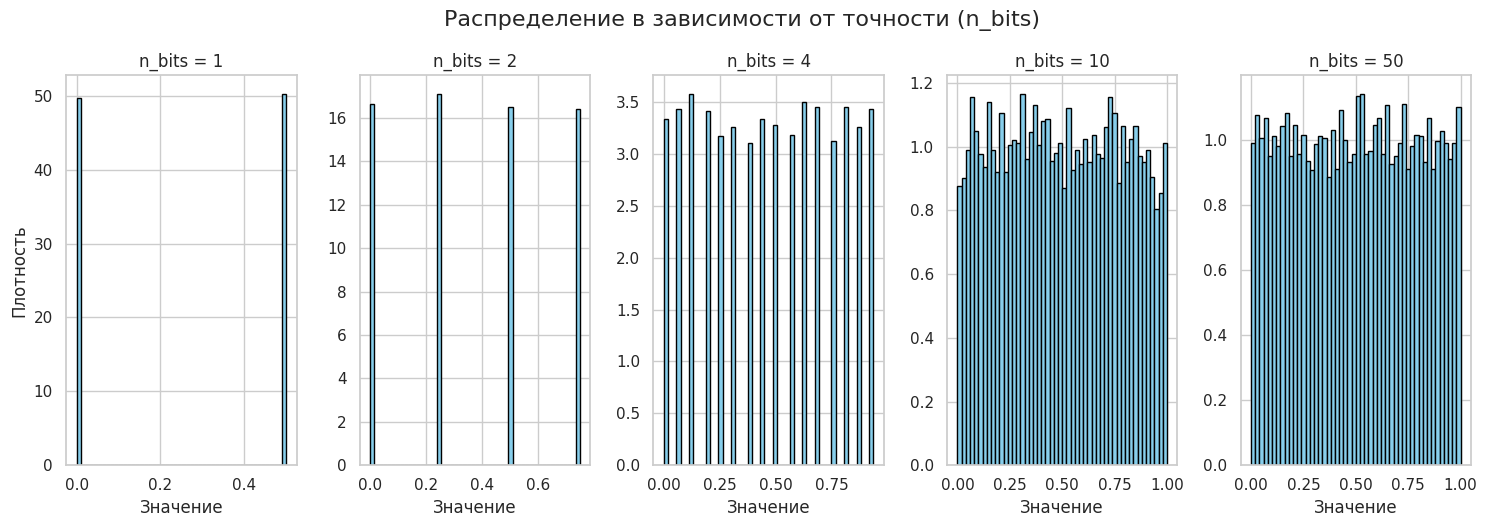

In [19]:
bits_to_test = [1, 2, 4, 10, 50]
sample_size = 10000

plt.figure(figsize=(15, 5))

for i, bits in enumerate(bits_to_test):
    data = uniform(sample_size, n_bits=bits)

    plt.subplot(1, len(bits_to_test), i + 1)
    plt.hist(data, bins=50, color='skyblue', edgecolor='black', density=True)
    plt.title(f'n_bits = {bits}')
    plt.xlabel('Значение')
    if i == 0: plt.ylabel('Плотность')

plt.tight_layout()
plt.suptitle("Распределение в зависимости от точности (n_bits)", fontsize=16, y=1.05)
plt.show()

**2.** Напишите функцию **`normal`** генерации случайных величин в количестве `size` штук из распределения $\mathcal{N}(loc, scale^2)$ с помощью преобразования Бокса-Мюллера.

Реализация должна быть без циклов. В качестве параметра `size` может быть как число, так и объект `tuple` любой размерности. Можно использовать реализованную ранее функцию `uniform`.

При реализации `normal` допускается использовать количество бросков монеты чуть больше оптимального с целью упрощения кода. А именно, для генерации выборки размера $n$ можно использовать броски монет не более того количества, которое требуется для оптимальной генерации выборки размера $n+1$.

In [20]:
def BoxMiller(x: float| np.ndarray, y:float|np.ndarray) -> tuple|np.ndarray:
  """
  На вход подуются либо две случайные величины из U(0, 1)
  Либо 2 массива одинаковой длинны состоящих из случайных величин U(0, 1)
  Параметры:
  ---------
  x: Первая случайная величина из равномерного распределения U(0, 1)
  y: Вторая случайная величина из равномерного распределения U(0, 1)

  Возвращает:
  Две случайные нормальные величины
  ----------
  """
  if isinstance(x, float) and isinstance(y, np.ndarray):
    raise TypeError("x и y должны быть одних типов")
  if isinstance(x, np.ndarray) and isinstance(y, float):
    raise TypeError("x и y должны быть одних типов")

  # Защита от x=0 для логарифма
  x = np.maximum(x, 1e-10)
  return np.sqrt(-2 * np.log(x)) * np.cos(2 * np.pi * y), np.sqrt(-2 * np.log(x)) * np.sin(2 * np.pi * y)

def normal(
    size: int | tuple = 1, loc: float = 0.0, scale: float = 1.0, n_bits: int = 50
) -> float | np.ndarray:
    """
    Генерирует выборку из нормального распределения N(loc, scale^2).

    Параметры
    ---------
    size: Размерность выходного массива (одно число для вектора или кортеж для тензора).
    loc: Математическое ожидание распределения.
    scale: Стандартное отклонение распределения (должно быть > 0).
    n_bits: Количество бросков честной монеты (битов) для базовой генерации U(0, 1).

    Возвращает
    ----------
    Сгенерированные значения из нормального распределения.
    """

    total = int(np.prod(size)) if isinstance(size, tuple) else size
    needed = total if total % 2 == 0 else total + 1
    X = uniform(needed, n_bits=n_bits)

    U1 = X[::2]
    U2 = X[1::2]

    Z0, Z1 = BoxMiller(U1, U2)

    uniform_array = np.concatenate([Z0, Z1])[:total]

    if isinstance(size, tuple) or (isinstance(size, int) and size > 1):
      return loc + scale * np.array(uniform_array).reshape(size)
    return loc + scale * uniform_array[0]


Cгенерируйте $200$ независимых случайных величин, постройте график плотности на отрезке $[-3, 3]$, а также гистограмму по сгенерированным случайным величинам.

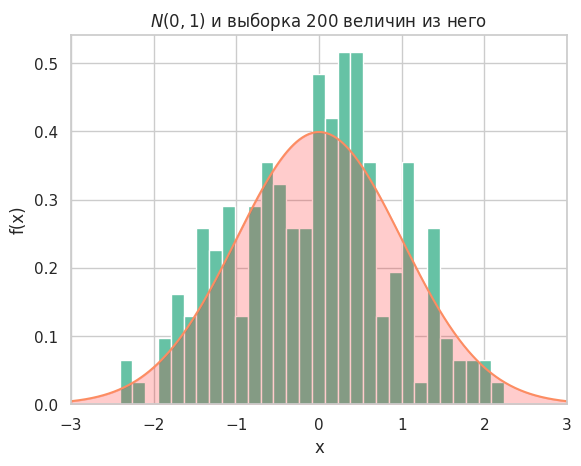

In [21]:
loc = 0
scale=1
sample = normal(200, loc=loc, scale=scale)
X = np.linspace(-3, 3, 500)
y = np.exp(-((X - loc) / scale)**2 / 2) / scale / np.sqrt(2 * np.pi)

plt.hist(sample, bins=30, density=True)
plt.plot(X, y)
plt.fill_between(X, y, alpha=0.2, color="red")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.xlim(-3, 3)
plt.title(f'$N({loc}, {scale})$ и выборка 200 величин из него')
plt.show()

**3.** Вы уже научились генерировать выборку из равномерного распределения. Напишите функцию **`expon`** генерации выборки из экспоненциального распределения, используя задачу из теории вероятностей:

*Если $\xi$ — случайная величина, имеющая абсолютно непрерывное распределение, и $F$ — ее функция распределения, то случайная величина $F(\xi)$ имеет равномерное распределение на $[0, 1]$*.

Если $F(\xi) \sim U(0, 1)$, то $\xi \sim F^{-1}(U)$. Теперь осталось найти $F^{-1}$ зная $F = 1 - e^{-\lambda x}$, $F^{-1}(x) = -\frac{1}{\lambda}ln(1 - x)$

In [22]:
def expon(size: int | tuple = 1, lambd: float = 1.0, n_bits: int = 50) -> float | np.ndarray:
    """
    Генерирует выборку из экспоненциального распределения Exp(lambd).

    Параметры
    ---------
    size: Размерность выходного массива (одно число для вектора или кортеж для тензора).
    lambd: Параметр интенсивности (должно быть > 0).
    n_bits: Количество бросков честной монеты (битов) для базовой генерации U(0, 1).

    Возвращает
    ----------
    Сгенерированные значения из экспоненциального распределения.
    """
    return -np.log(1 - uniform(size, n_bits=n_bits)) / lambd

Для $Exp(1)$ сгенерируйте выборку размера 200 и постройте график плотности этого распределения на отрезке $[-0.5, 5]$.

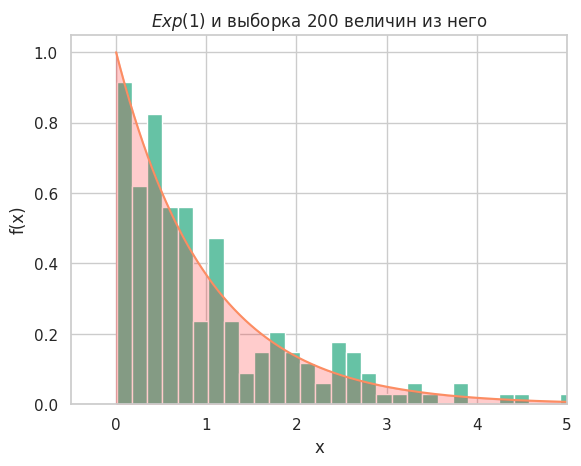

In [23]:
lambd=1
sample = expon(200, lambd=1)
X = np.linspace(-0, 5, 500)
y = lambd * np.exp(-lambd * X)

plt.hist(sample, bins=30, density=True)
plt.plot(X, y)
plt.fill_between(X, y, alpha=0.2, color="red")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.xlim(-0.5, 5)
plt.title(f'$Exp({lambd})$ и выборка 200 величин из него')
plt.show()

**4. Выводы:**

1. **Генерация из базовых распределений:** Если мы имеем одну случайную величину Bern(1/2), то с помощью ее мы можем сгенерировать любое абсолютно непрерывное распределение.
2. **Точность аппроксимации:** Приближение распределения зависит от количества бит. `n_bits`. Мы фактически приближаем дискретным распределением абсолютно непрерывное.
3. **Преобразования:** Получив базовое распределение $U(0, 1)$, мы можем трансформировать его в любые другие. Векторизация `numpy` позволяет выполнять эти операции эффективно и без циклов.

---

### Задача 2.

Рассмотрим <a target="_black" href="https://ru.wikipedia.org/wiki/Распределение_Коши">распределение Коши</a> с плотностью
$$p(x) = \frac{1}{\pi(1+x^2)}$$
для $x\in\mathbb{R}$, которое известно своими <a target="_black" href="https://en.wikipedia.org/wiki/Heavy-tailed_distribution">тяжелыми хвостами</a>. Иначе говоря, плотность убывает медленно при $x \to \infty$ (точное определение может различаться для разных источников). Сравните, например, с нормальным или экспоненциальным распределениями. В частности, из-за этого у распределения Коши даже не существует математического ожидания.

За распределение Коши отвечает класс <a target="_black" href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.cauchy.html">`scipy.stats.cauchy`</a>.

**1.** Визуализируйте на одном графики плотности нормального распределения и распределения Коши. Что можно сказать?

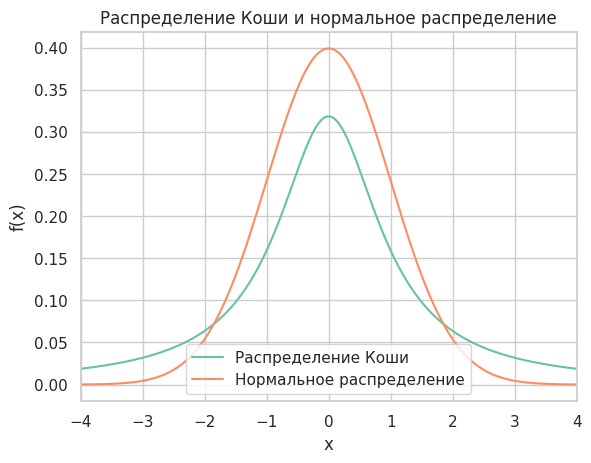

In [24]:
import scipy.stats as sps
X = np.linspace(-4, 4, 500)
y_cauchy = sps.cauchy.pdf(X)
y_normal = sps.norm.pdf(X)
plt.plot(X, y_cauchy, label="Распределение Коши")
plt.plot(X, y_normal, label="Нормальное распределение")
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.xlim(-4, 4)
plt.title("Распределение Коши и нормальное распределение")
plt.show()

Можно сказать, что хвосты у Коши больше чем у нормального. При больших |x| плотность Коши убывает медленнее.
Поэтому вблизи нуля плотность нормального выше, а в хвостах плотноть коши выше -> у коши чаще возникают выбросы.

**2.** Повторите эксперимент с <a href="https://thetahat.ru/courses/ad/main/9/2_lln" target="_top">занятия</a> про закон больших чисел для распределения Коши. Выполняется ли закон?

(0.0, 1000.0)

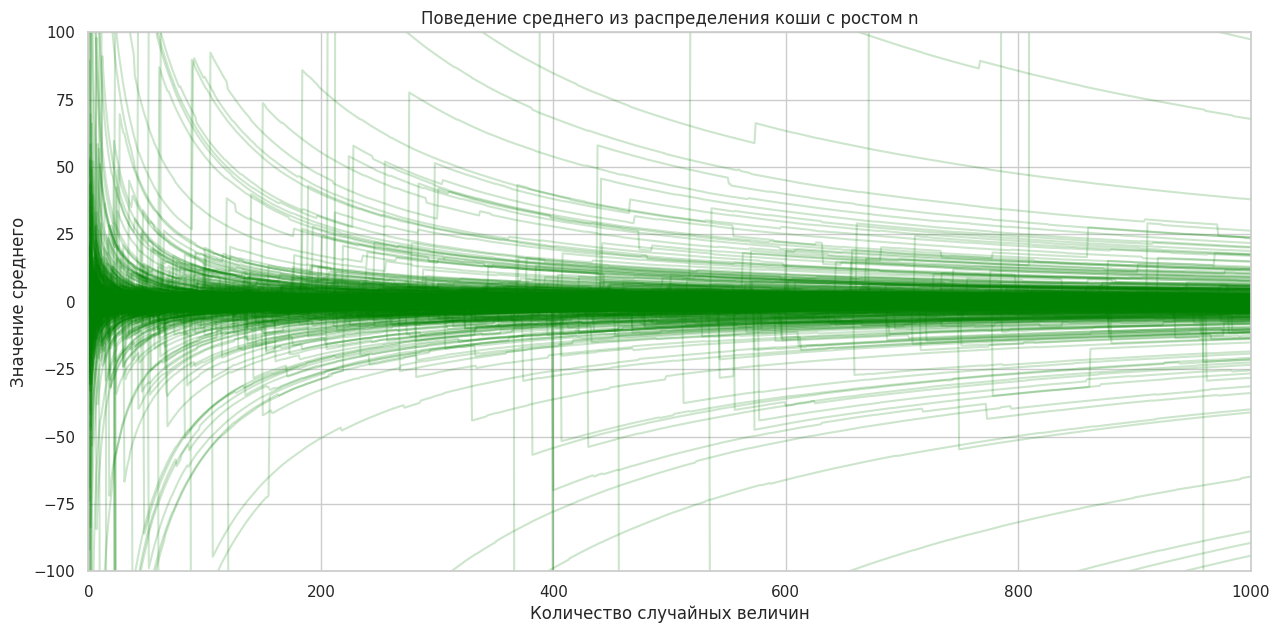

In [25]:
size = 1000
samples_count = 1000
samples = sps.cauchy.rvs(size=(samples_count, size))
cum_sum = samples.cumsum(axis=1) / (np.arange(size) + 1)

# Строим график
plt.figure(figsize=(15, 7))

# рисуем для каждой выборки отдельно
for i in range(samples_count):
    plt.plot(np.arange(size) + 1, cum_sum[i], color="green", alpha=0.2)

plt.xlabel("Количество случайных величин")
plt.ylabel("Значение среднего")
plt.title("Поведение среднего из распределения коши с ростом n")
plt.ylim(-100, 100)
plt.xlim((0, size))

Как видно из графика, нет такого интервала, в который все праектории будут попадать начиная с какогото n.
Найдем, к чему стремится случайная величина: $\frac{X_1 + ... + X_N}{N}$. Характеристическая функция Коши : $exp(-\sigma |t|)$
При сложении, характеристические функции перемножаются:
$X_1 + ... + X_N \sim exp(-n\sigma |t|)$.
Теперь найдем характеристическую функцию $\bar{X}$.
$\phi_{\bar{X}}(x) = \mathbb{E}(exp(-it\bar{X})) = \mathbb{E}(exp(-\frac{itX}{N})) = \phi_{X}(\frac{t}{N})$ Подставляя характеристическую функцию суммы независимых $X_1, ... X_N \sim Cauchy(\sigma)$ получаем, что распределение среднего - тоже $Cauchy(\sigma)$
То есть распределение выборочного среднего никак не меняется с ростом n. -> среднее не сходится к константе и ЗБЧ не преминим.

**3.** Аналогичным образом проведите эксперимент по изучению сходимости *выборочной* медианы при увеличении размера выборки. Медиану по выборке можно посчитать с помощью <a target="_blank" href="https://numpy.org/doc/stable/reference/generated/numpy.median.html">`np.median`</a>.

/tmp/ipykernel_17232/2265117931.py:4: FutureWarning: Support for axis=1 in DataFrame.expanding is deprecated and will be removed in a future version. Use obj.T.expanding(...) instead
  cum_median = pd.DataFrame(samples).expanding(axis=1).median().values


(0.0, 500.0)

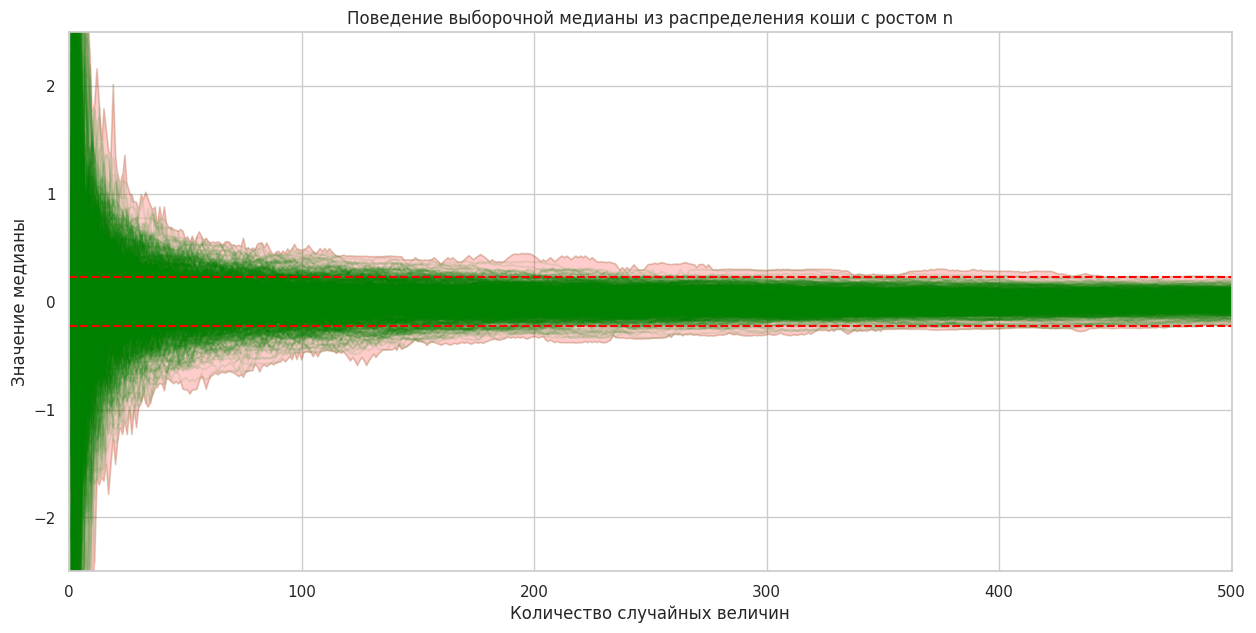

In [26]:
size = 500
samples_count = 1000
samples = sps.cauchy.rvs(size=(samples_count, size))
cum_median = pd.DataFrame(samples).expanding(axis=1).median().values
# Строим график
plt.figure(figsize=(15, 7))

# рисуем для каждой выборки отдельно
for i in range(samples_count):
    plt.plot(np.arange(size) + 1, cum_median[i], color="green", alpha=0.1)

# Трубка, в которую попадают все траектории
lower_bound = np.quantile(cum_median, 0, axis=0)
upper_bound = np.quantile(cum_median, 1, axis=0)

# Добавляем горизонтальные линии
plt.axhline(lower_bound[-1], color='red', linestyle='--', label=f'Квантиль 0.025 ({lower_bound[-1]:.3f})')
plt.axhline(upper_bound[-1], color='red', linestyle='--', label=f'Квантиль 0.975 ({upper_bound[-1]:.3f})')

plt.fill_between(np.arange(size) + 1, lower_bound, upper_bound,
                 color="red", alpha=0.2)

plt.xlabel("Количество случайных величин")
plt.ylabel("Значение медианы")
plt.title("Поведение выборочной медианы из распределения коши с ростом n")
plt.ylim(-2.5, 2.5)
plt.xlim((0, size))

**4. Вывод:**

- ЗБЧ работает не всегда
- У распределения Коши хвосты тяжелее, чем у нормалного распределения, поэтому часто встречаются большие выбросы

- Распределение выборочного среднего имеет то же распределение, что и отдельные наблюдения. Поэтому с ростом размера выборка среднее не стремится к константе.

- Основной вывод: для распределений с тяжелыми хвостами выборочное среднее может быть плохой оценкой центра. Есть более хорошие оценки центра, такие как медиана.

---
### Задача 3.

Перед выполнением этой задачи настоятельно рекомендуется посмотреть <a href="https://thetahat.ru/courses/ad/main/9/2_lln" target="_top">ноутбук</a> с лекции про закон больших чисел.

На практике не редко возникает вопрос &mdash; **сколько времени потребуется на сбор данных, чтобы оценить среднее с достаточной точностью**. Для ответа на этот вопрос можно использовать различные теоретические оценки, в частности, неравенство Чебышева.

Другой способ &mdash; смоделировать большое количество выборок. Предположим, что мы сгенерировали $K$ выборок размера $n$ каждая, и $M_{nj}$ &mdash; *выборочное* среднее элементов в $j$-й выборке. Пусть математическое ожидание равно $a$, будем считать его известным в данной задаче. Тогда в качестве меры отклонения от среднего *среднее значение модуля отклонения от $a$*, то есть
$$F(n) = \frac{1}{K}\sum\limits_{j=1}^{K} \left|M_{nj} - a \right|,$$

**1.** Рассмотрим распределения $Bern(a)$ для $a=0.5$. Пусть для нас допустимо отклонение на 0.02, иначе говоря при *истинном* среднем 0.5 мы считаем достаточно точными значения *выборочного* среднего от 0.48 до 0.52. Тогда в качестве *приближения* необходимого размера выборок можно взять наименьшее значение $n$, при котором $F(n) \leqslant 0.02$.

Реализуйте данный эксперимент для $K=500$ и найдите значение $n$. Визуализируйте зависимость $F(n)$ от $n$ в обычном и логарифмическом масштабах (по тем осям, по которым это имеет смысл).

Для реализации без циклов стоит генерировать достаточно большие выборки и использовать функцию `np.where`.

Минимальное n: 3012


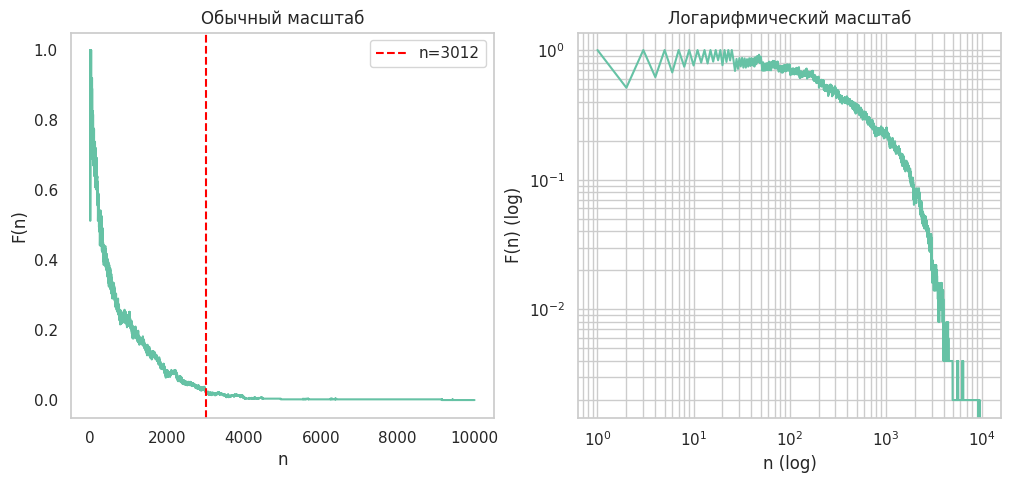

In [27]:
K = 500
max_n = 10000
p = 0.5
eps = 0.02
samples = sps.bernoulli.rvs(p, size=(K, max_n))
cum_sum = samples.cumsum(axis=1) / np.arange(1, max_n + 1)

F_n = (np.abs(cum_sum - p) > eps).mean(axis=0)

indices = np.where(F_n <= 0.02)[0]
min_n = indices[0] + 1 if len(indices) > 0 else None

print(f"Минимальное n: {min_n}")

# Визуализация
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.arange(1, max_n + 1), F_n)
plt.axvline(min_n, color='red', linestyle='--', label=f'n={min_n}')
plt.title('Обычный масштаб')
plt.xlabel('n'); plt.ylabel('F(n)'); plt.grid(); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(np.arange(1, max_n + 1), F_n)
plt.xscale('log')
plt.yscale('log')
plt.title('Логарифмический масштаб')
plt.xlabel('n (log)'); plt.ylabel('F(n) (log)'); plt.grid(True, which="both")
plt.show()

**Вывод**
Мы получили приближенную оценку $n \approx 3152$

**2.** Повторите эксперимент из пункта 1 для значений $a$ от 0.05 до 0.95 с шагом 0.05. Визуализируйте зависимость необходимого размера выборки $n$ от значения $a$.

При реализации можно сделать цикл по значениям $a$.

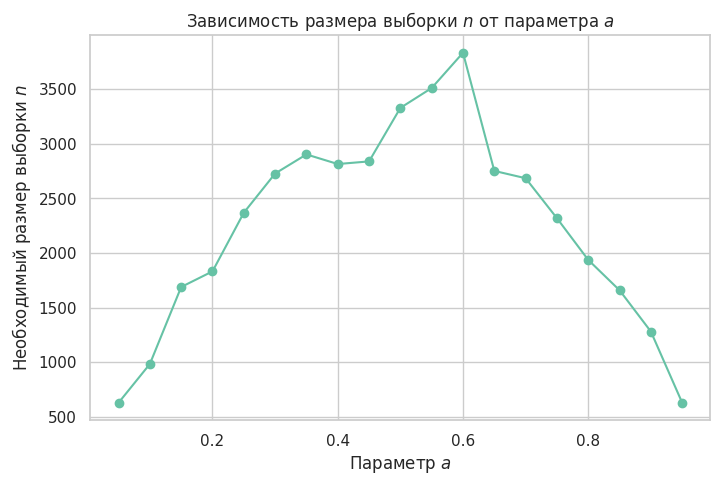

In [28]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt

K = 500
max_n = 10000
eps = 0.02
threshold = 0.02

a_values = np.arange(0.05, 0.96, 0.05)
n_values = []

for a in a_values:
    samples = sps.bernoulli.rvs(a, size=(K, max_n))
    cum_means = np.cumsum(samples, axis=1) / np.arange(1, max_n + 1)
    F_n = (np.abs(cum_means - a) > eps).mean(axis=0)
    indices = np.where(F_n <= threshold)[0]
    min_n = indices[0] + 1 if len(indices) > 0 else None

    n_values.append(min_n)

#Визуализация
plt.figure(figsize=(8, 5))
plt.plot(a_values, n_values, marker='o', linestyle='-')
plt.title('Зависимость размера выборки $n$ от параметра $a$')
plt.xlabel('Параметр $a$')
plt.ylabel('Необходимый размер выборки $n$')
plt.grid(True)
plt.show()

**Вывод**
- Максимум при a=0.5
- при a -> 0, a->1 нужный размер выборки уменьшается
- Это верно, так как $\mathbb{Var}(X) = a(1-a)$ и вершина этой параболы: a = 0.5
- Это объясняет то, что график +- симметричен относительно a=0.5

**3.** В теории часто предполагается независимость элементов выборки, однако, на практике это не всегда так. Исследуем, насколько это влияет на сходимость средних. Повторите эксперимент пункта 1, используя вместо выборки генерацию марковской цепи на значениях 0 и 1 с матрицей переходных вероятностей
$$
\begin{pmatrix}
p & 1-p \\
1-p & p
\end{pmatrix}.
$$

При $p=1/2$ мы получаем генерацию выборки из независимых случайных величин $Bern(1/2)$. При других значениях $p$ мы также получаем случайные величины из $Bern(1/2)$, но они уже зависимы друг с другом.

Проведите эксперимент для значений $p$ от 0.05 до 0.95 с шагом 0.05. Визуализируйте зависимость необходимого размера выборки $n$ от значения $p$.

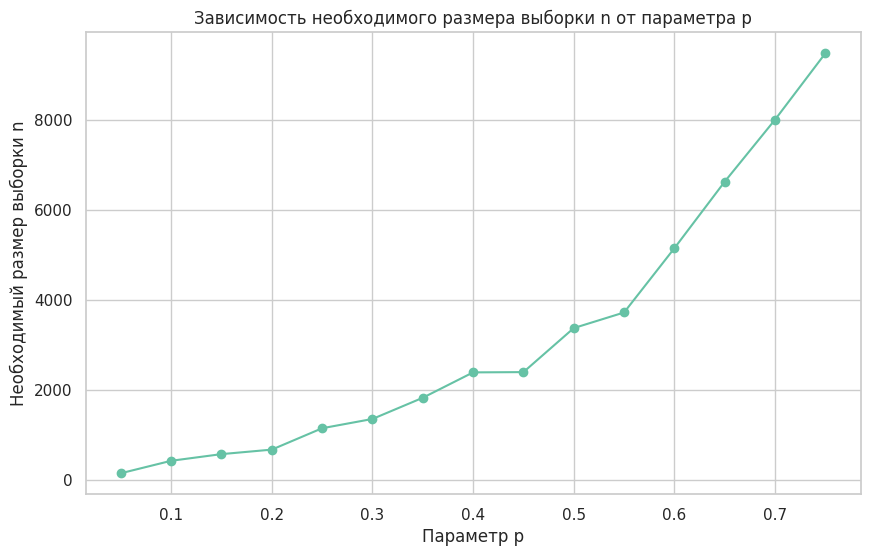

In [29]:
import numpy as np
import matplotlib.pyplot as plt

K = 500
max_n = 10000
eps = 0.02
threshold = 0.02

def required_n_markov(p, K=500, max_n=10000, eps=0.02, threshold=0.02):
    # начальные состояния 0 или 1 равновероятно
    x0 = np.random.randint(0, 2, size=(K, 1))

    #Это индикаторы смены цепи. 1 - поменять, а иначе оставить
    flips = (np.random.rand(K, max_n - 1) > p).astype(int)

    # Построение марковской Цепи
    chain = np.concatenate(
        [x0, (x0 + np.cumsum(flips, axis=1)) % 2],
        axis=1
    )

    cum_means = np.cumsum(chain, axis=1) / np.arange(1, max_n + 1)
    F_n = (np.abs(cum_means - 0.5) > eps).mean(axis=0)

    indices = np.where(F_n <= threshold)[0]
    min_n = indices[0] + 1 if len(indices) > 0 else None

    return min_n, F_n

p_values = np.arange(0.05, 1.0, 0.05)
n_needed = []

for p in p_values:
    min_n, _ = required_n_markov(p, K=K, max_n=max_n, eps=eps, threshold=threshold)
    n_needed.append(min_n)

plt.figure(figsize=(10, 6))
plt.plot(p_values, n_needed, marker='o')
plt.title('Зависимость необходимого размера выборки n от параметра p')
plt.xlabel('Параметр p')
plt.ylabel('Необходимый размер выборки n')
plt.grid(True)
plt.show()

При p = 0.5 мы получаем обычную сходимость.
При $p > 0.5$ цепь стремится сохранять значение.При $p < 0.5$ цепь стремится менять значение.
Откуда, если p малое, то последовательность ведет себя похоже на 10101010101
А если p большое, то будут длинные блоки из 0 и 1. Откуда, при малых p будет очень быстрая сходимость, а при больших p длинные блоки будум мешать сходимости.

**4. Выводы:**

**Выводы**

- В пункте 1 мы оценивали вероятность $
F(n)=\mathbb{P}\left(\left|\overline X_n-a\right|>\varepsilon\right)$
методом Монте-Карло. Мы нашли, примерно с какого n минимальное значение погрешности меньше 0.02

- В пункте 2 мы посмотрели, что будет при разных a,  а не только при a = 0.5

- В 3-м пункте мы поняли, что зависимость между наблюдениями существенно влияет на скорость сходимости.

- То есть на скорость сходимости влияют разные факторы, и не только то, из какого распределения величины, но и то, насколько они зависимы.

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для ВвАД